# Lab 02 — Tasks 1, 2 & 3
## Medical Image Enhancement, Cardiac Image Fusion & Echocardiogram Video Analysis

This notebook combines all three tasks from **Lab 02** into one notebook.

### Tasks
1. **Diagnostic Enhancement of Chest X-Rays**
2. **Multi-Modal Cardiac Image Fusion (CT + MRI)**
3. **Real-Time Echocardiogram Video Analysis**

> Put only the sample files actually used by the notebook inside the corresponding `data/` folders. Do **not** upload the complete datasets to GitHub.

In [1]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# DATA + OUTPUT DIRECTORIES
# ============================================================

BASE_DIR = Path(".")

DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "output"

DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# TASK 1 - X-RAY
# ============================================================

xray_path = DATA_DIR / "xray.png"

if not xray_path.exists():
    raise FileNotFoundError(f"X-ray not found: {xray_path}")

xray = cv2.imread(str(xray_path), cv2.IMREAD_GRAYSCALE)

print("Task 1 X-Ray:", xray_path)


# ============================================================
# TASK 2 - CT + MRI
# ============================================================

ct_path = DATA_DIR / "ct.png"
mri_path = DATA_DIR / "mri.png"

if not ct_path.exists():
    raise FileNotFoundError(f"CT not found: {ct_path}")

if not mri_path.exists():
    raise FileNotFoundError(f"MRI not found: {mri_path}")

ct = cv2.imread(str(ct_path), cv2.IMREAD_GRAYSCALE)
mri = cv2.imread(str(mri_path), cv2.IMREAD_GRAYSCALE)

print("Task 2 CT :", ct_path)
print("Task 2 MRI:", mri_path)


# ============================================================
# TASK 3 - ECHO / ULTRASOUND
# ============================================================

echo_path = DATA_DIR / "echo.mp4"

if not echo_path.exists():
    raise FileNotFoundError(f"Echo video not found: {echo_path}")

cap = cv2.VideoCapture(str(echo_path))

print("Task 3 Echo:", echo_path)


# ============================================================
# CHECK
# ============================================================


if cap.isOpened():
    print("Echo video: Successfully opened")
else:
    print("Echo video: Could not open")


Task 1 X-Ray: data\xray.png
Task 2 CT : data\ct.png
Task 2 MRI: data\mri.png
Task 3 Echo: data\echo.mp4
Echo video: Successfully opened


In [2]:
def list_images(folder):
    return sorted([
        p for p in Path(folder).rglob("*")
        if p.is_file()
        and p.suffix.lower() in IMAGE_EXTENSIONS
    ])


def read_grayscale(path):
    image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)

    if image is None:
        raise ValueError(f"Could not read image: {path}")

    return image


def histogram_equalization(image):
    return cv2.equalizeHist(image)


def color_balance_shift(image, shift=0):
    image = image.astype(np.int16) + shift
    image = np.clip(image, 0, 255)
    return image.astype(np.uint8)


def show_images(images, titles, cmaps=None, figsize=(14, 5)):
    plt.figure(figsize=figsize)

    for i, image in enumerate(images):
        plt.subplot(1, len(images), i + 1)

        if cmaps:
            plt.imshow(image, cmap=cmaps[i])
        else:
            plt.imshow(image)

        plt.title(titles[i])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Task 1 — Diagnostic Enhancement of Chest X-Rays

Required operations:
- Load and display a sample grayscale X-ray.
- Histogram equalization.
- False-color mapping using `cv2.COLORMAP_JET`.
- Color-balance adjustment.
- Thresholding to isolate high-intensity/dense tissue.
- Logarithmic transformation.
- Power-law/gamma transformation with `gamma < 1`.

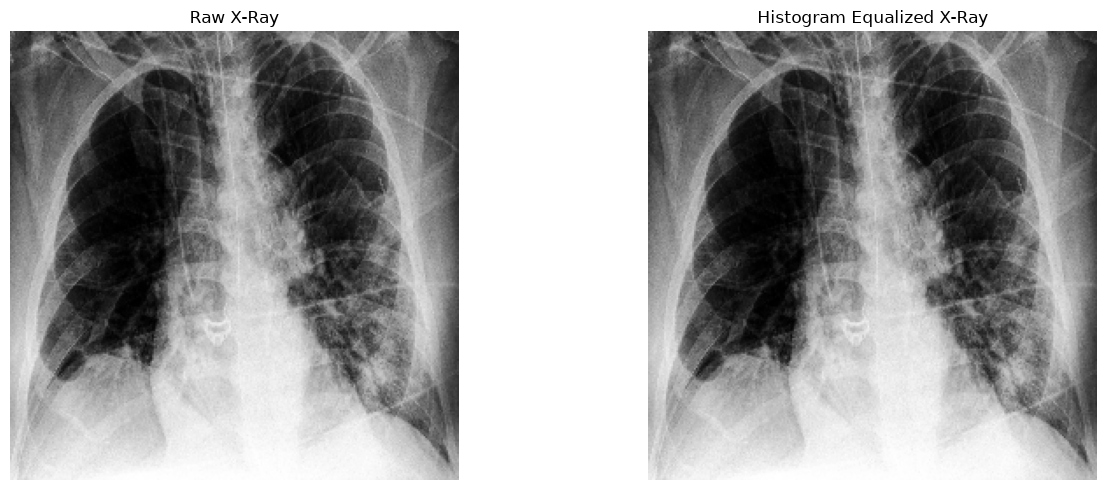

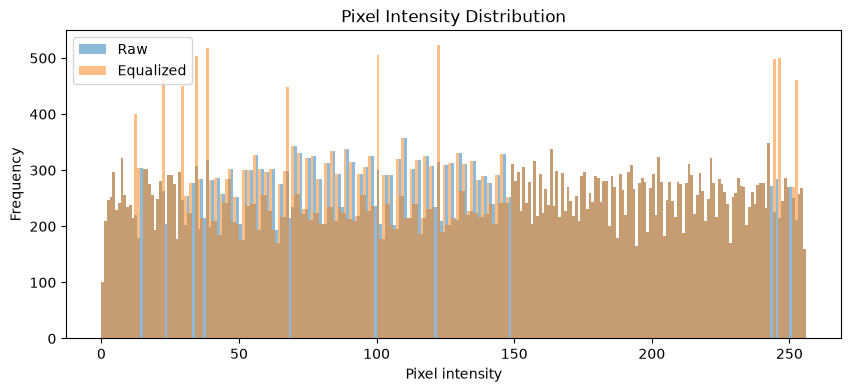

In [3]:
# ============================================================
# Task 1: Histogram Equalization
# ============================================================

xray_equalized = histogram_equalization(xray)

show_images(
    [xray, xray_equalized],
    ["Raw X-Ray", "Histogram Equalized X-Ray"],
    ["gray", "gray"],
    figsize=(14, 5)
)

plt.figure(figsize=(10, 4))
plt.hist(xray.ravel(), bins=256, range=(0, 256), alpha=0.5, label="Raw")
plt.hist(
    xray_equalized.ravel(),
    bins=256,
    range=(0, 256),
    alpha=0.5,
    label="Equalized"
)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel intensity")
plt.ylabel("Frequency")
plt.legend()
plt.show()

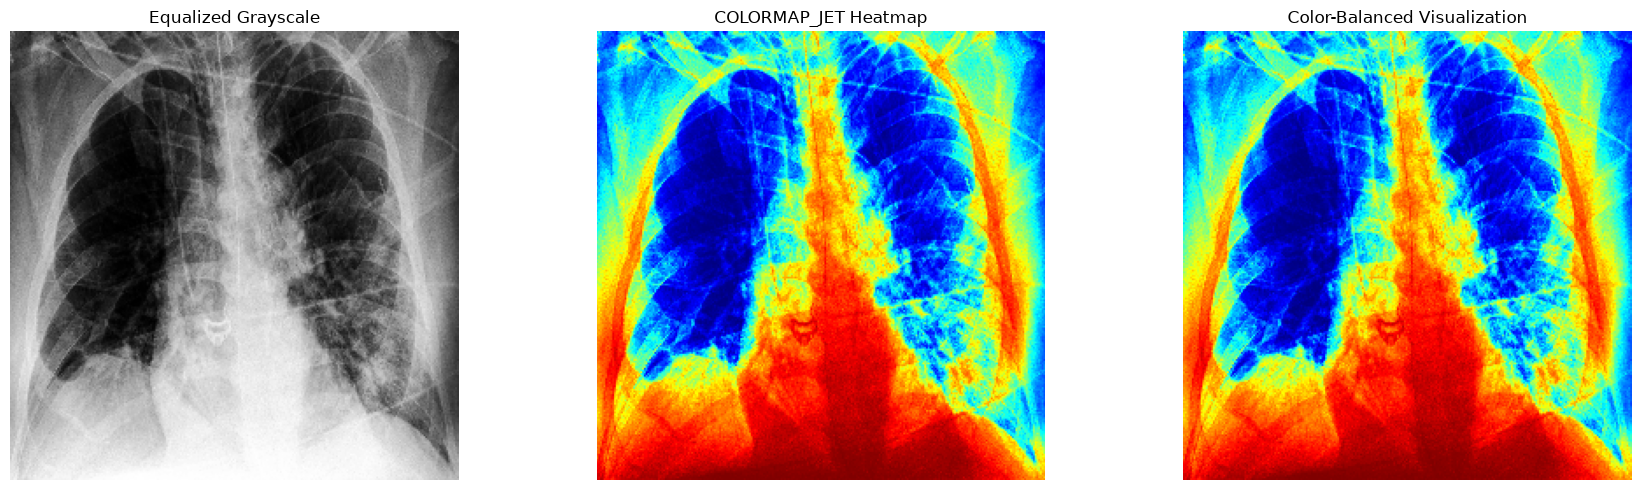

In [4]:
# ============================================================
# Task 1: Color Mapping + Color Balance
# ============================================================

# False-color heatmap using the required COLORMAP_JET.
xray_heatmap = cv2.applyColorMap(xray_equalized, cv2.COLORMAP_JET)
xray_heatmap_rgb = cv2.cvtColor(xray_heatmap, cv2.COLOR_BGR2RGB)

# Neutral color-balance correction.
xray_balanced = color_balance_shift(xray_heatmap, shift=0)
xray_balanced_rgb = cv2.cvtColor(xray_balanced, cv2.COLOR_BGR2RGB)

show_images(
    [xray_equalized, xray_heatmap_rgb, xray_balanced_rgb],
    [
        "Equalized Grayscale",
        "COLORMAP_JET Heatmap",
        "Color-Balanced Visualization"
    ],
    ["gray", None, None],
    figsize=(18, 5)
)

Automatically selected threshold: 127.0


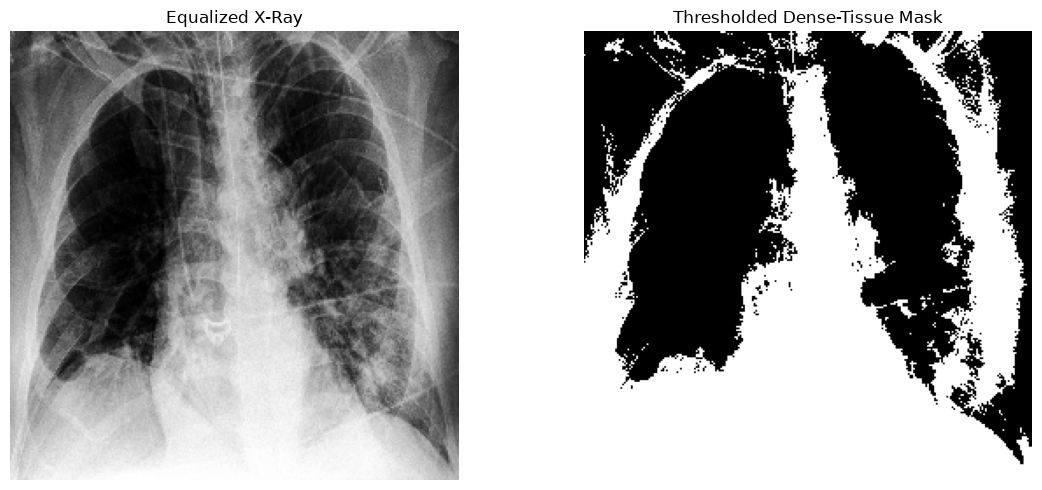

In [5]:
# ============================================================
# Task 1: Color Filtering / Thresholding
# ============================================================

# Otsu thresholding selects the threshold automatically from
# the intensity distribution.
threshold_value, xray_threshold = cv2.threshold(
    xray_equalized,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

print("Automatically selected threshold:", threshold_value)

show_images(
    [xray_equalized, xray_threshold],
    ["Equalized X-Ray", "Thresholded Dense-Tissue Mask"],
    ["gray", "gray"],
    figsize=(12, 5)
)

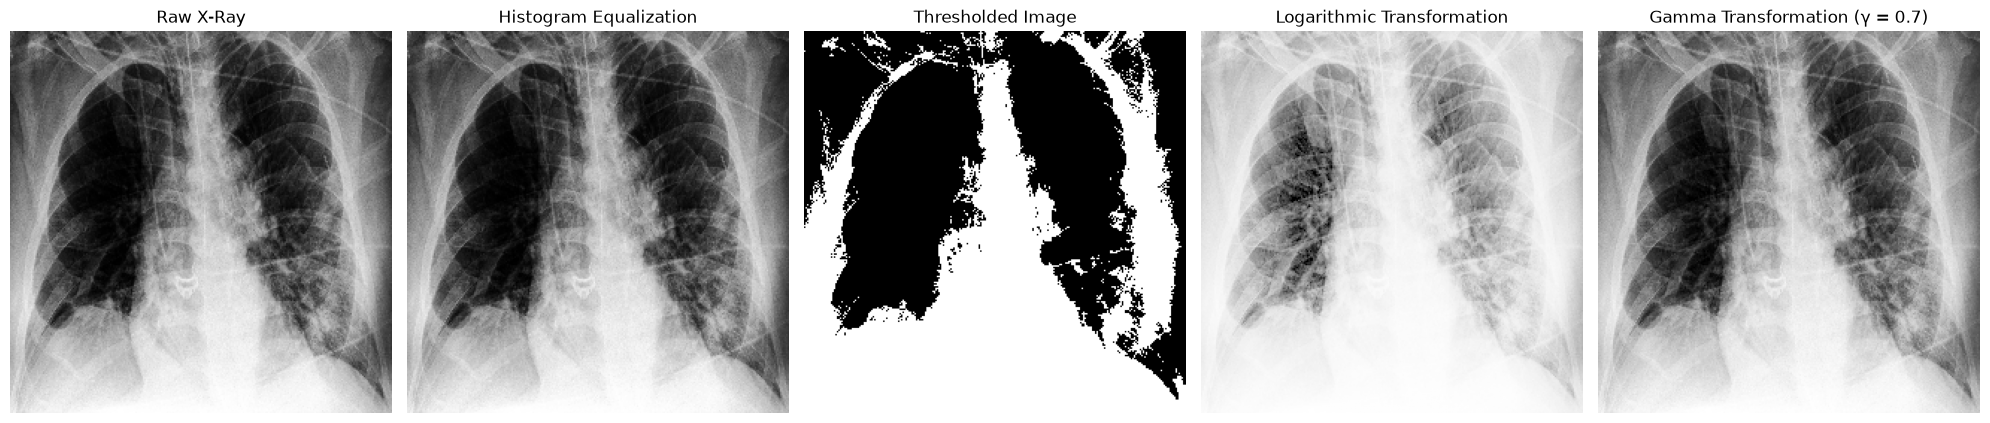

In [7]:
# ============================================================
# Task 1: Logarithmic + Power-Law Transformations
# ============================================================
# ============================================================
# Image Transformation Functions
# ============================================================

def logarithmic_transform(image):
    image = image.astype(np.float32)

    # c = 255 / log(1 + max_pixel)
    c = 255 / np.log(1 + np.max(image))

    log_image = c * np.log(1 + image)

    return np.uint8(np.clip(log_image, 0, 255))


def gamma_transform(image, gamma=0.7):
    image = image.astype(np.float32) / 255.0

    gamma_image = np.power(image, gamma)

    return np.uint8(gamma_image * 255)


def show_images(images, titles, cmaps=None, figsize=(15, 5)):
    plt.figure(figsize=figsize)

    for i, image in enumerate(images):
        plt.subplot(1, len(images), i + 1)

        if cmaps:
            plt.imshow(image, cmap=cmaps[i])
        else:
            plt.imshow(image)

        plt.title(titles[i])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

xray_log = logarithmic_transform(xray)
xray_gamma = gamma_transform(xray, gamma=0.7)

show_images(
    [xray, xray_equalized, xray_threshold, xray_log, xray_gamma],
    [
        "Raw X-Ray",
        "Histogram Equalization",
        "Thresholded Image",
        "Logarithmic Transformation",
        "Gamma Transformation (γ = 0.7)"
    ],
    ["gray"] * 5,
    figsize=(20, 5)
)

# Task 2 — Multi-Modal Cardiac Image Fusion

The CT and MRI slices should represent the **same heart region and corresponding pair**.

Required operations:
- Load one CT slice and its corresponding MRI slice.
- Histogram equalization on both modalities.
- Color mapping.
- Overlay/fusion.
- Weighted fusion using `cv2.addWeighted()`, with a **heavier CT weight**.
- Logarithmic and power-law transformations.
- Side-by-side comparison of CT, MRI and fused output.

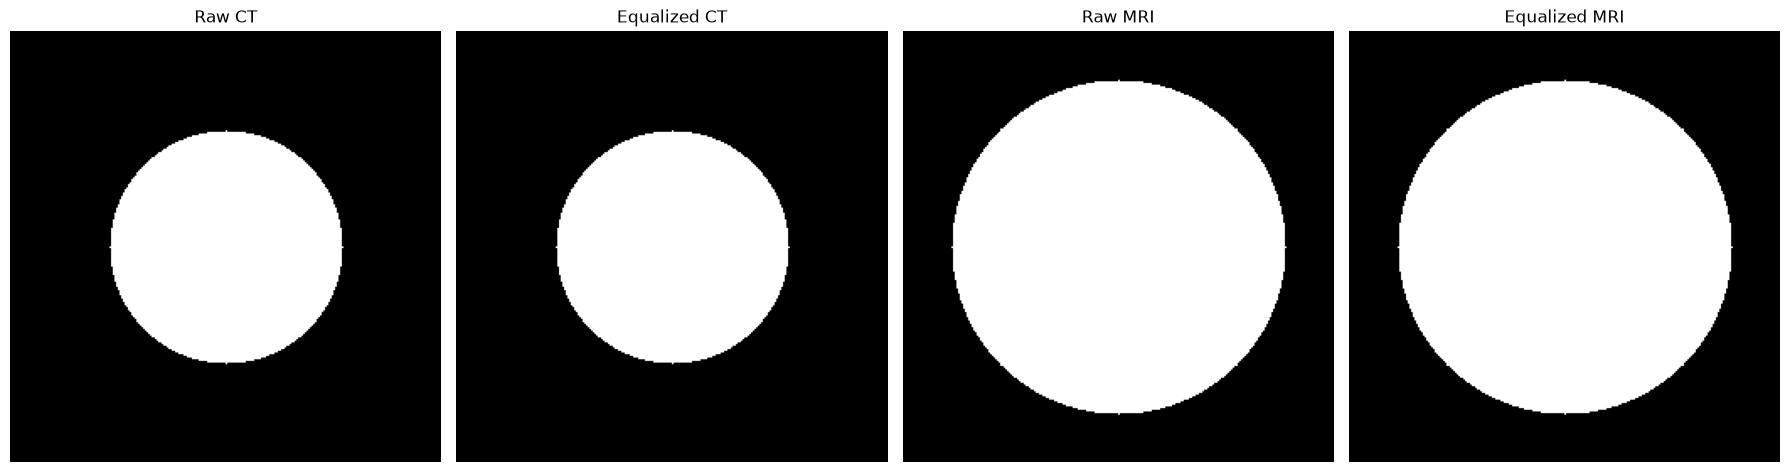

In [9]:
# ============================================================
# Task 2: Histogram Equalization
# ============================================================

ct_eq = histogram_equalization(ct)
mri_eq = histogram_equalization(mri)

show_images(
    [ct, ct_eq, mri, mri_eq],
    ["Raw CT", "Equalized CT", "Raw MRI", "Equalized MRI"],
    ["gray"] * 4,
    figsize=(18, 5)
)

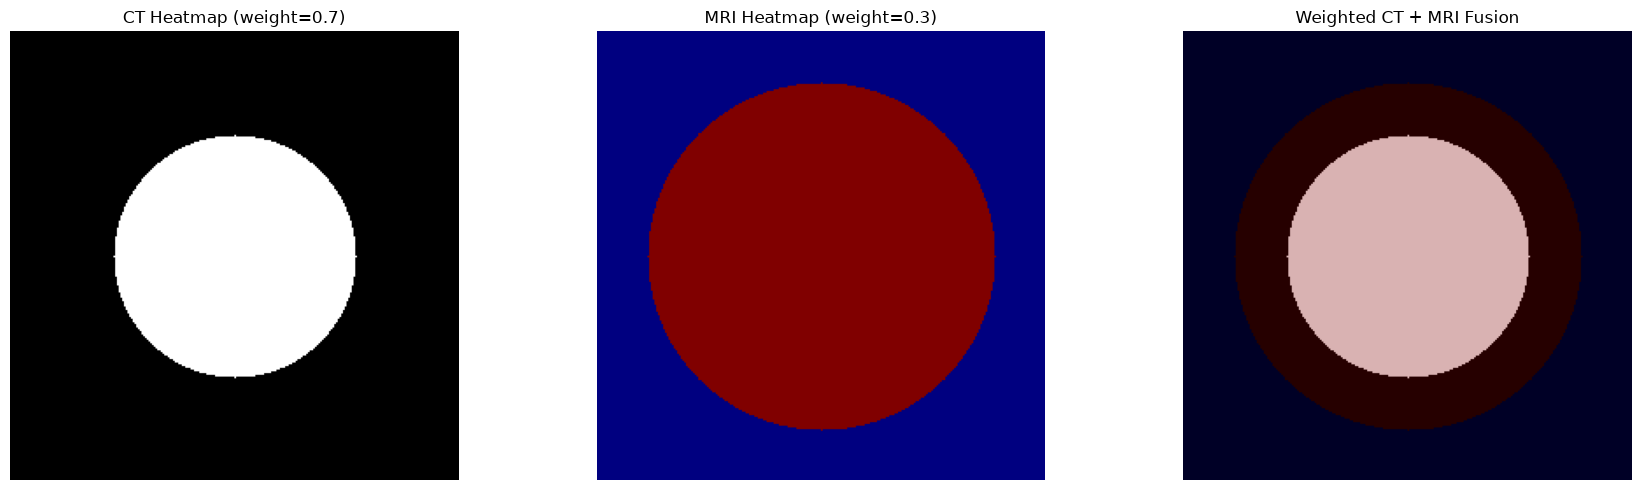

In [10]:
# ============================================================
# Task 2: Color Mapping and Weighted Fusion
# ============================================================

# Different heatmaps allow the two modalities to remain
# visually distinguishable in the fused result.
ct_color = cv2.applyColorMap(ct_eq, cv2.COLORMAP_HOT)
mri_color = cv2.applyColorMap(mri_eq, cv2.COLORMAP_JET)

# Heavier CT weight preserves sharper anatomical boundaries.
CT_WEIGHT = 0.70
MRI_WEIGHT = 0.30

fused = cv2.addWeighted(
    ct_color,
    CT_WEIGHT,
    mri_color,
    MRI_WEIGHT,
    0
)

ct_rgb = cv2.cvtColor(ct_color, cv2.COLOR_BGR2RGB)
mri_rgb = cv2.cvtColor(mri_color, cv2.COLOR_BGR2RGB)
fused_rgb = cv2.cvtColor(fused, cv2.COLOR_BGR2RGB)

show_images(
    [ct_rgb, mri_rgb, fused_rgb],
    [
        f"CT Heatmap (weight={CT_WEIGHT})",
        f"MRI Heatmap (weight={MRI_WEIGHT})",
        "Weighted CT + MRI Fusion"
    ],
    [None, None, None],
    figsize=(18, 5)
)

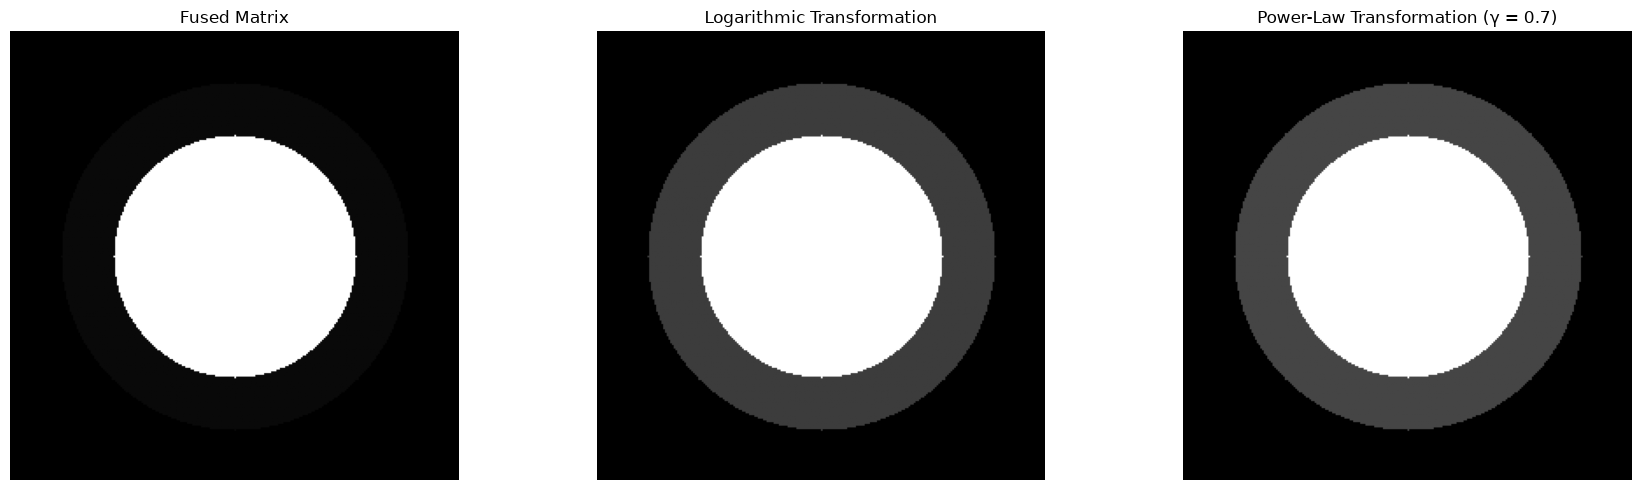

In [11]:
# ============================================================
# Task 2: Logarithmic + Power-Law Transformations
# ============================================================

fused_gray = cv2.cvtColor(fused, cv2.COLOR_BGR2GRAY)

fused_log = logarithmic_transform(fused_gray)
fused_gamma = gamma_transform(fused_log, gamma=0.7)

show_images(
    [fused_gray, fused_log, fused_gamma],
    [
        "Fused Matrix",
        "Logarithmic Transformation",
        "Power-Law Transformation (γ = 0.7)"
    ],
    ["gray", "gray", "gray"],
    figsize=(18, 5)
)

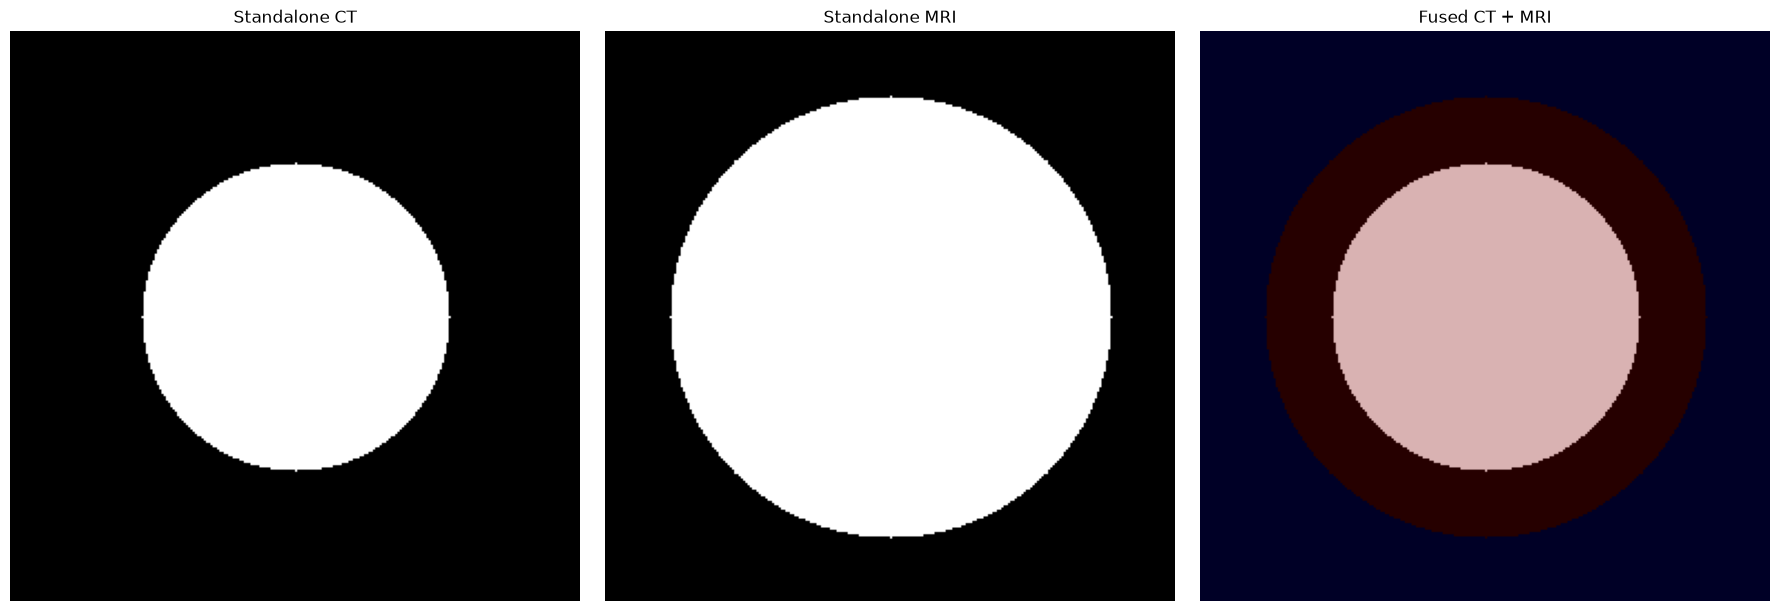

In [12]:
# ============================================================
# Task 2: Comparative Analysis
# ============================================================

show_images(
    [ct, mri, fused_rgb],
    ["Standalone CT", "Standalone MRI", "Fused CT + MRI"],
    ["gray", "gray", None],
    figsize=(18, 6)
)

# Task 3 — Real-Time Echocardiogram Video Analysis

The lab requires a real-time OpenCV pipeline that:
- reads the provided `.mp4` ultrasound file using `cv2.VideoCapture()`;
- processes frames continuously in a `while` loop;
- applies histogram equalization;
- applies `COLORMAP_JET`;
- applies color-balance adjustment;
- applies logarithmic transformation;
- applies a power-law transformation;
- displays raw and enhanced frames side-by-side using `cv2.imshow()`.

In [13]:
# ============================================================
# Task 3: Frame enhancement pipeline
# ============================================================

def enhance_echo_frame(frame_bgr, gamma=0.7):
    """Apply all required enhancements to one echo frame."""

    # Convert frame to a single-channel intensity matrix.
    gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)

    # 1. Histogram equalization
    equalized = cv2.equalizeHist(gray)

    # 2. False-color heatmap
    heatmap = cv2.applyColorMap(equalized, cv2.COLORMAP_JET)

    # 3. Color-balance adjustment
    balanced = color_balance_shift(heatmap, shift=0)

    # 4. Logarithmic transformation
    log_img = logarithmic_transform(equalized)

    # 5. Power-law transformation
    gamma_img = gamma_transform(log_img, gamma=gamma)

    # Final mathematical enhancement as BGR for display.
    final_bgr = cv2.cvtColor(gamma_img, cv2.COLOR_GRAY2BGR)

    return balanced, final_bgr

In [15]:
# ============================================================
# Task 3: Real-time OpenCV video loop
# ============================================================

cap = cv2.VideoCapture(str(echo_path))

if not cap.isOpened():
    raise RuntimeError(f"Could not open video: {echo_path}")

while True:
    ret, frame = cap.read()

    if not ret:
        break

    cv2.imshow("Echo Ultrasound", frame)

    # Press q to stop
    if cv2.waitKey(30) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()


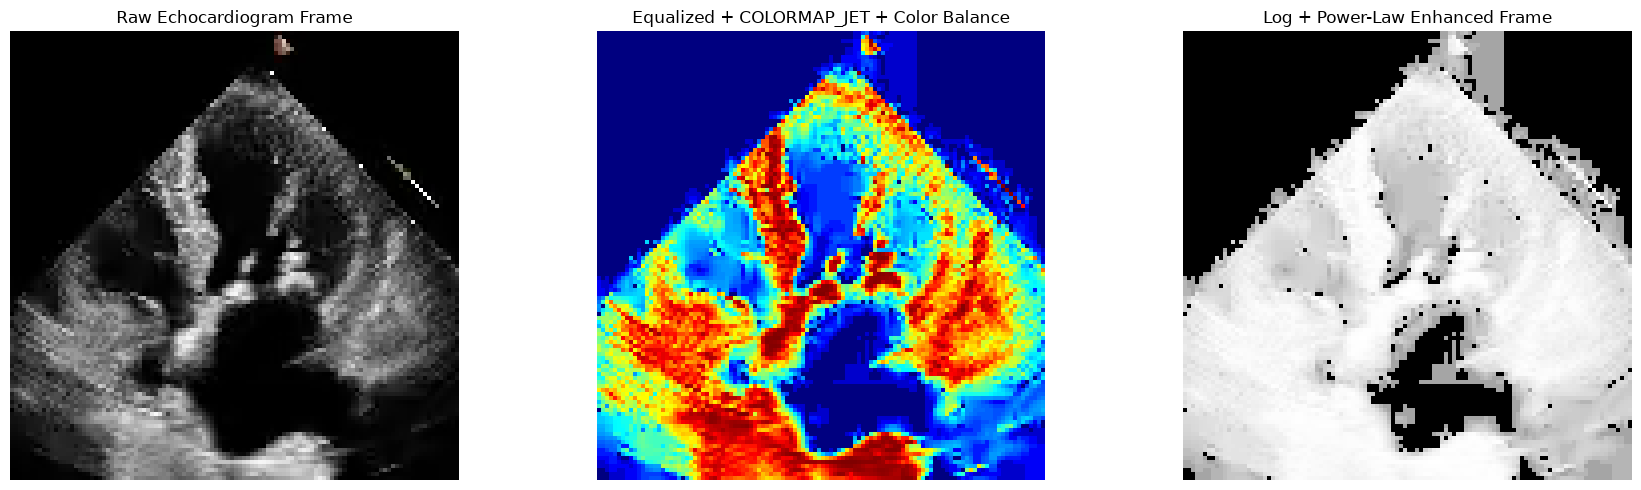

In [17]:
# ============================================================
# Task 3: Jupyter-friendly single-frame preview
# ============================================================

cap_preview = cv2.VideoCapture(str(echo_path))

ret, preview_frame = cap_preview.read()
cap_preview.release()

if not ret:
    raise RuntimeError("Could not read the first video frame.")

preview_heatmap, preview_final = enhance_echo_frame(
    preview_frame,
    gamma=0.7
)

preview_raw_rgb = cv2.cvtColor(
    preview_frame,
    cv2.COLOR_BGR2RGB
)

preview_heatmap_rgb = cv2.cvtColor(
    preview_heatmap,
    cv2.COLOR_BGR2RGB
)

preview_final_gray = cv2.cvtColor(
    preview_final,
    cv2.COLOR_BGR2GRAY
)

show_images(
    [preview_raw_rgb, preview_heatmap_rgb, preview_final_gray],
    [
        "Raw Echocardiogram Frame",
        "Equalized + COLORMAP_JET + Color Balance",
        "Log + Power-Law Enhanced Frame"
    ],
    [None, None, "gray"],
    figsize=(18, 5)
)